# EDA — Silver Layer (data bersih)

Analisis pada `fact_harga_pasar.csv` hasil preprocessing final. Data:
- 6 pasar Surabaya × 37 komoditas × 2020-2026
- Analytics memakai `harga_imputasi` (kontinu); statistik statistik harga memakai
  `harga_asli` (`is_imputed=False`) agar bebas artefak imputasi.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)

fact = pd.read_csv("../data/processed/fact_harga_pasar.csv", parse_dates=["tanggal"])
prod = pd.read_csv("../data/processed/fact_harga_produsen.csv", parse_dates=["tanggal"])
dim_pasar = pd.read_csv("../data/processed/dim_pasar.csv")

fp = fact.merge(dim_pasar[["pasar_id", "nama_pasar"]], on="pasar_id")
print(f"fact: {len(fp):,} baris | {fp['tanggal'].min():%Y-%m-%d} s.d. {fp['tanggal'].max():%Y-%m-%d}")

fact: 477,097 baris | 2020-01-01 s.d. 2026-08-31


## 1. Kualitas data per pasar
Persentase baris imputasi per pasar — Soponyono terbesar karena pencatatan paling jarang.

,n_hari,pct_imputed
nama_pasar,,
Pasar Keputran,2435,8.2
Pasar Genteng,2435,4.5
Pasar Tambahrejo,2435,4.5
Pasar Wonokromo,2435,2.8
Pasar Soponyono,1428,2.4
Pasar Pucang Anom,2435,0.2


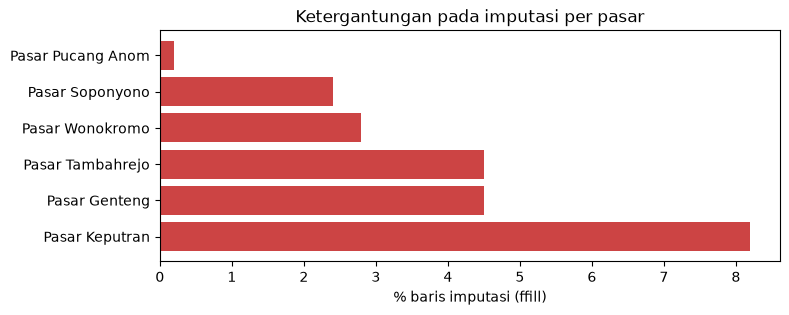

In [2]:
ringkas = (fp.groupby("nama_pasar")
             .agg(n_hari=("tanggal", "nunique"),
                  pct_imputed=("is_imputed", lambda s: round(100 * s.mean(), 1)))
             .sort_values("pct_imputed", ascending=False))
display(ringkas)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(ringkas.index, ringkas["pct_imputed"], color="#c44")
ax.set_xlabel("% baris imputasi (ffill)")
ax.set_title("Ketergantungan pada imputasi per pasar")
plt.show()

## 2. Tren harga komoditas kunci (rata-rata antar pasar, harga asli saja)

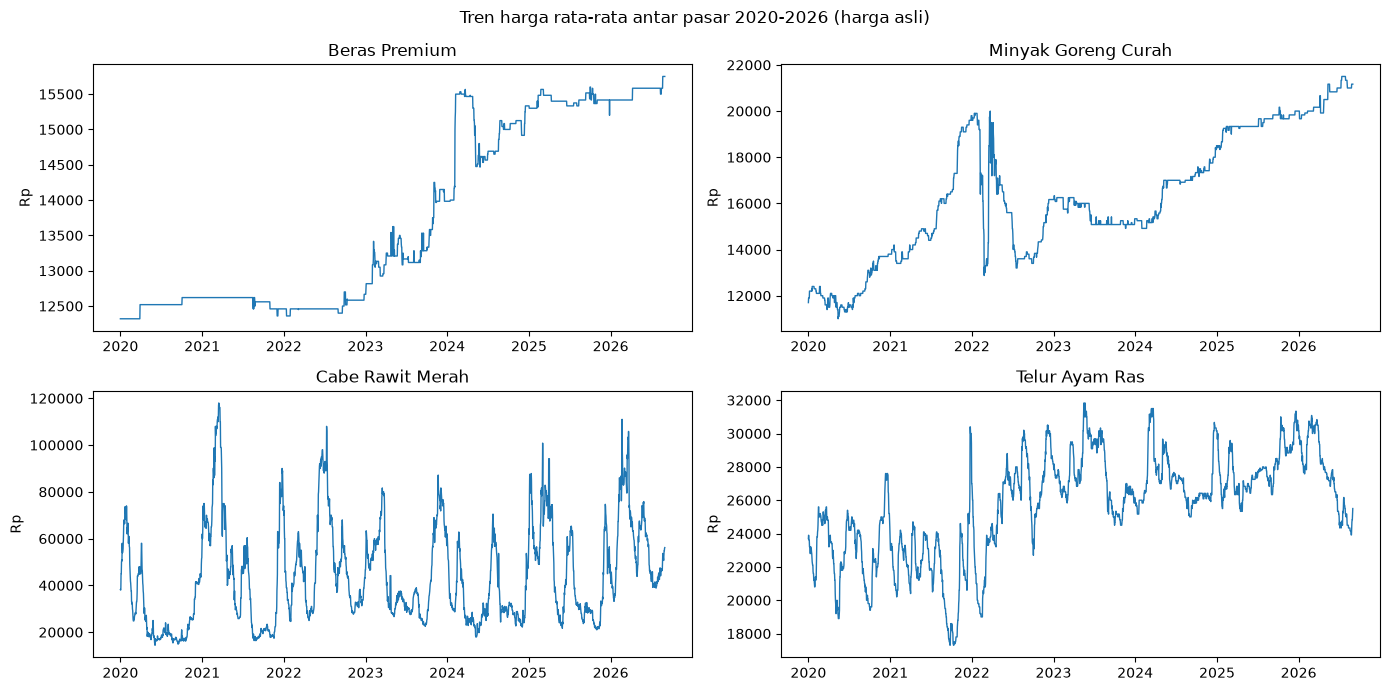

In [3]:
kunci = ["Beras Premium", "Minyak Goreng Curah", "Cabe Rawit Merah", "Telur Ayam Ras"]
tren = (fact[fact["komoditas"].isin(kunci) & ~fact["is_imputed"]]
        .groupby(["tanggal", "komoditas"])["harga_asli"].mean().unstack())

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, kol in zip(axes.flat, kunci):
    ax.plot(tren.index, tren[kol], lw=1)
    ax.set_title(kol)
    ax.set_ylabel("Rp")
fig.suptitle("Tren harga rata-rata antar pasar 2020-2026 (harga asli)")
fig.tight_layout()
plt.show()

## 3. Volatilitas per komoditas
Std dari perubahan harga harian (%) — komoditas paling fluktuatif vs paling stabil.

C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_22252\1005505126.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  vol = (piv.pct_change().std() * 100).dropna().sort_values()


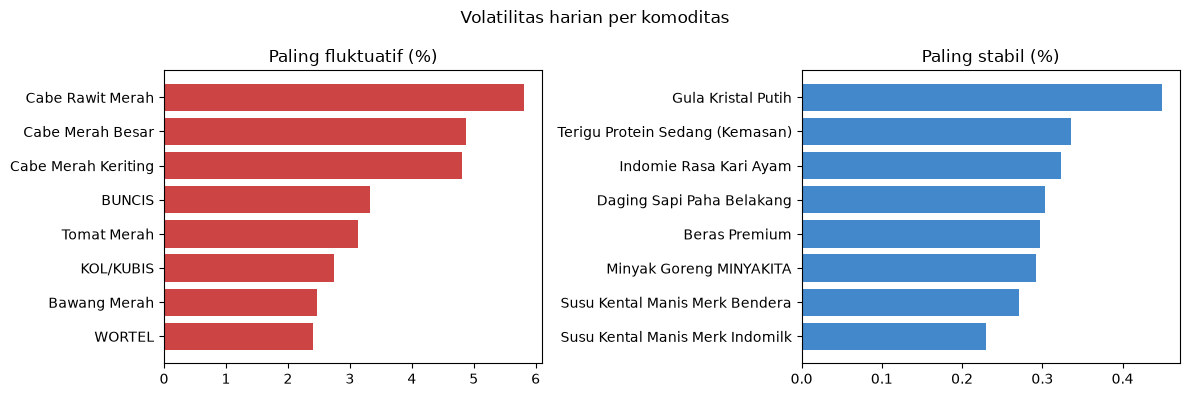

komoditas
WORTEL                 2.40
Bawang Merah           2.46
KOL/KUBIS              2.74
Tomat Merah            3.13
BUNCIS                 3.33
Cabe Merah Keriting    4.81
Cabe Merah Besar       4.87
Cabe Rawit Merah       5.82
dtype: float64

In [4]:
piv = (fact[~fact["is_imputed"]]
       .groupby(["tanggal", "komoditas"])["harga_asli"].mean().unstack())
vol = (piv.pct_change().std() * 100).dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(vol.tail(8).index, vol.tail(8).values, color="#c44")
axes[0].set_title("Paling fluktuatif (%)")
axes[1].barh(vol.head(8).index, vol.head(8).values, color="#48c")
axes[1].set_title("Paling stabil (%)")
fig.suptitle("Volatilitas harian per komoditas")
fig.tight_layout()
plt.show()

vol.tail(8).round(2)

## 4. Market comparison — harga terbaru per pasar

In [5]:
tgl_akhir = fact["tanggal"].max()
terakhir = fp[(fp["tanggal"] == tgl_akhir) & fp["komoditas"].isin(kunci)]
piv = terakhir.pivot_table(index="komoditas", columns="nama_pasar",
                           values="harga_imputasi", aggfunc="mean")
piv["selisih_min_max"] = (piv.max(axis=1) - piv.min(axis=1)).round(0)
piv

nama_pasar,Pasar Genteng,Pasar Keputran,Pasar Pucang Anom,Pasar Soponyono,Pasar Tambahrejo,Pasar Wonokromo,selisih_min_max
komoditas,,,,,,,
Beras Premium,14500.0,16000.0,17000.0,15000.0,16500.0,15500.0,2500.0
Cabe Rawit Merah,60000.0,40000.0,60000.0,64000.0,55000.0,58000.0,24000.0
Minyak Goreng Curah,23000.0,20000.0,20000.0,22000.0,20000.0,22000.0,3000.0
Telur Ayam Ras,26000.0,24000.0,27000.0,25000.0,25000.0,26000.0,3000.0


## 5. Margin produsen → konsumen
Harga konsumen rata-rata pasar dikurangi harga produsen titik pantau Surabaya.

C:\Users\Nicolaus Prima\AppData\Local\Temp\ipykernel_22252\3464177504.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


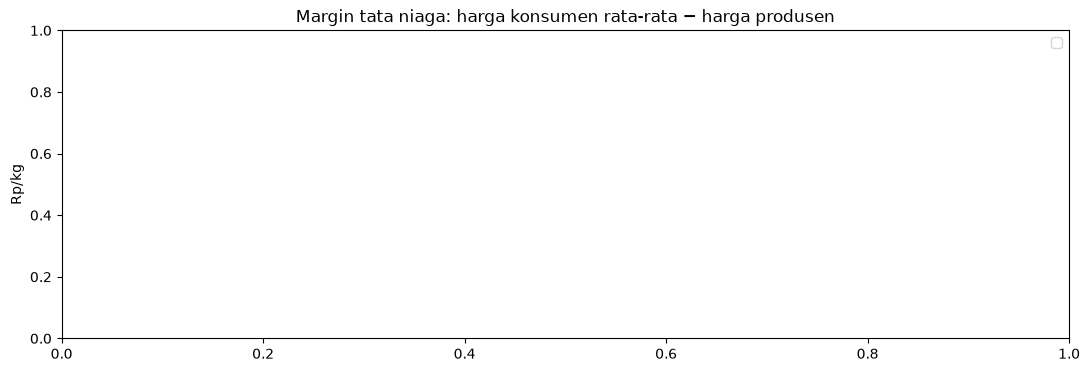

In [6]:
pasangan = {"Beras": "PS Bendul Mrisi", "Daging Sapi": "RPH Pegirikan"}

hasil_margin = {}
for kom, titik in pasangan.items():
    konsumen = (fact[(fact["komoditas"] == kom) & ~fact["is_imputed"]]
                .groupby("tanggal")["harga_asli"].mean())
    produsen = (prod[(prod["komoditas"] == kom) & (prod["titik_pantau"] == titik)
                     & ~prod["is_imputed"]]
                .groupby("tanggal")["harga_asli"].mean())
    margin = (konsumen - produsen).dropna()
    hasil_margin[kom] = margin
    if len(margin):
        print(f"{kom}: margin rata-rata Rp{margin.mean():,.0f}/kg "
              f"(min Rp{margin.min():,.0f}, maks Rp{margin.max():,.0f}, "
              f"{len(margin)} hari)")

fig, ax = plt.subplots(figsize=(13, 4))
for kom, margin in hasil_margin.items():
    if len(margin):
        ax.plot(margin.index, margin, lw=1, label=kom)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Margin tata niaga: harga konsumen rata-rata − harga produsen")
ax.set_ylabel("Rp/kg")
ax.legend()
plt.show()

## 6. Efek Ramadan — rata-rata harga pra-Ramadan vs normal
Periode pra-Ramadan (14 hari sebelum) dibandingkan hari biasa, per komoditas kunci.

In [7]:
kal = pd.read_csv("../data/processed/dim_kalender.csv", parse_dates=["tanggal"])
fpk = fp.merge(kal[["tanggal", "is_ramadan", "is_pra_ramadan"]], on="tanggal", how="left")

baris = []
for kom in ["Beras Premium", "Cabe Rawit Merah", "Bawang Merah", "Telur Ayam Ras", "Gula Kristal Putih"]:
    d = fpk[(fpk["komoditas"] == kom) & ~fpk["is_imputed"]]
    pra = d[d["is_pra_ramadan"] == 1]["harga_asli"].mean()
    biasa = d[(d["is_pra_ramadan"] == 0) & (d["is_ramadan"] == 0)]["harga_asli"].mean()
    baris.append({"komoditas": kom,
                  "harga_normal": round(biasa),
                  "harga_pra_ramadan": round(pra),
                  "selisih_pct": round(100 * (pra - biasa) / biasa, 1)})
pd.DataFrame(baris)

,komoditas,harga_normal,harga_pra_ramadan,selisih_pct
0,Beras Premium,13809,13956,1.1
1,Cabe Rawit Merah,42835,60356,40.9
2,Bawang Merah,32781,32465,-1.0
3,Telur Ayam Ras,25873,26864,3.8
4,Gula Kristal Putih,14761,15449,4.7


## Kesimpulan cepat
- Imputasi hanya 3,8% baris; Soponyono paling tinggi (pencatatan jarang) — pertimbangkan bobot khusus.
- Volatilitas tertinggi di komoditas segar (cabe, bawang) — target utama early warning.
- Margin tata niaga & efek Ramadan bisa dihitung langsung dari silver layer ini.